In [1]:
%cd /content/drive/MyDrive/ArticleClassificationData

/content/drive/MyDrive/ArticleClassificationData


# Train Model

## Import Data

In [ ]:
import pandas as pd
df = pd.read_pickle('finalarticle1683.pkl')
df['pmid'] = df['pmid'].astype(str)
df = df.drop_duplicates(subset=['pmid'])
text_columns = ['title', 'abstract']
label_column = 'label'

## Make 5 KF_DF

In [ ]:
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=10)
kf5_df = pd.DataFrame(columns = ['train_df','val_df','test_df','accuracy','report','roc_auc','roc_curve'])

In [ ]:
for train_idx, valid_idx in kf.split(df,df['label']):
    train_df = df.iloc[train_idx]
    val_test_df = df.iloc[valid_idx]
    val_df, test_df = train_test_split(val_test_df, test_size=0.5, random_state=10, stratify=val_test_df['label'])
    kf5_df = pd.concat([kf5_df, pd.DataFrame({'train_df': [train_df], 'val_df': [val_df], 'test_df': [test_df]})], ignore_index=True)

In [ ]:
kf5_df.iloc[2]['val_df']

In [ ]:
kf5_df.to_pickle('finalarticle1683_kf5.pkl')

## Install Packages

In [ ]:
!pip install --upgrade fastai
!pip install --upgrade transformers
!pip install --upgrade accelerate

## Import Packages

In [3]:
from fastai.text.all import *
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report,roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import torch
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification

## Import kf5

In [4]:
kf5_df = pd.read_pickle('finalarticle1683_kf5.pkl')

## Code

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-v1.1')
keywords ='gene' #list(genes)
tokenizer.add_tokens(keywords)

In [ ]:
class AdaptedModel(nn.Module):
    def __init__(self, model, num_labels):
        super().__init__()
        self.model = model
        self.linear = nn.Linear(self.model.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        logits = self.linear(pooled_output)
        return logits

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SuggestedLRs(valley=4.365158383734524e-05)

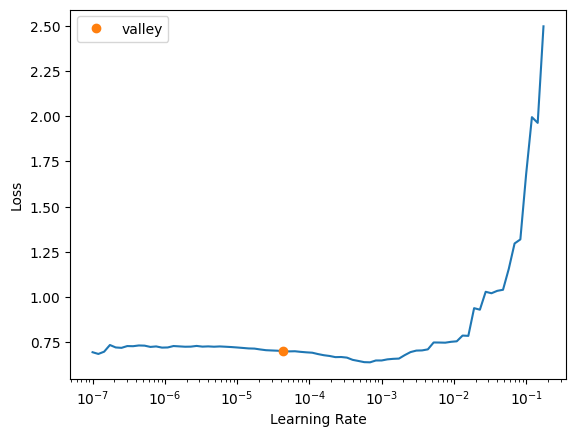

In [ ]:
i = 1
train_df = kf5_df['train_df'][i]
val_df = kf5_df['val_df'][i]
test_df = kf5_df['test_df'][i]
text_columns = ['title', 'abstract']
label_column = 'label'

train_tokens = tokenizer(list(train_df[text_columns[0]].values), list(train_df[text_columns[1]].values), truncation=True, padding=True, is_split_into_words=False)
val_tokens = tokenizer(list(val_df[text_columns[0]].values), list(val_df[text_columns[1]].values), truncation=True, padding=True, is_split_into_words=False)
test_tokens = tokenizer(list(test_df[text_columns[0]].values), list(test_df[text_columns[1]].values), truncation=True, padding=True, is_split_into_words=False)

label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df[label_column])
val_labels = label_encoder.transform(val_df[label_column])
test_labels = label_encoder.transform(test_df[label_column])

bs = 16  # Batch size
train_ds = list(zip(torch.tensor(train_tokens['input_ids']), torch.tensor(train_tokens['attention_mask']), torch.tensor(train_labels)))
valid_ds = list(zip(torch.tensor(val_tokens['input_ids']), torch.tensor(val_tokens['attention_mask']), torch.tensor(val_labels)))
test_ds = list(zip(torch.tensor(test_tokens['input_ids']), torch.tensor(test_tokens['attention_mask']), torch.tensor(test_labels)))

train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)
valid_dl = DataLoader(valid_ds, batch_size=bs * 4)
test_dl = DataLoader(test_ds, batch_size=bs * 4)

model = AutoModelForSequenceClassification.from_pretrained('dmis-lab/biobert-v1.1', num_labels=2)
adapted_model = AdaptedModel(model.bert, num_labels=2)
adapted_model.model.resize_token_embeddings(len(tokenizer))
adapted_model.to(device)

dls = DataLoaders(train_dl, valid_dl)
learn = Learner(dls, adapted_model, loss_func=nn.CrossEntropyLoss(), metrics=accuracy )
learn = learn.to_fp16()

lr = learn.lr_find();lr

In [ ]:
save_model_cb = SaveModelCallback(monitor='accuracy', fname='best_accuracy_model')

In [ ]:
learn.fit_one_cycle(10, lr_max=slice(4e-7, lr), cbs=[save_model_cb] , wd=0.1)

epoch,train_loss,valid_loss,accuracy,time
0,0.607418,0.518125,0.773810,00:53
1,0.404005,0.383390,0.839286,00:54
2,0.276408,0.447315,0.833333,00:53
3,0.142734,0.614772,0.797619,00:53
4,0.075968,0.528521,0.851190,00:53
5,0.038634,0.666963,0.845238,00:53
6,0.021627,0.618679,0.845238,00:53
7,0.009717,0.649800,0.863095,00:53
8,0.003432,0.654982,0.857143,00:53
9,0.001496,0.653955,0.851190,00:53


Better model found at epoch 0 with accuracy value: 0.773809552192688.
Better model found at epoch 1 with accuracy value: 0.8392857313156128.
Better model found at epoch 4 with accuracy value: 0.851190447807312.
Better model found at epoch 7 with accuracy value: 0.863095223903656.


In [ ]:
learn.load('best_accuracy_model')

In [ ]:
torch.save(learn.model, 'model_onkf_1.pkl')

In [ ]:
preds, targets = learn.get_preds(dl=test_dl)
predicted_labels = preds.argmax(dim=1).cpu().numpy()
true_labels = targets.flatten().cpu().numpy()
kf5_df.at[i,'accuracy'] = accuracy_score(true_labels, predicted_labels)
kf5_df.at[i,'report'] = classification_report(true_labels, predicted_labels, output_dict=True)
kf5_df.at[i,'roc_auc'] = roc_auc_score(true_labels, preds[:, 1].numpy())
kf5_df.at[i,'roc_curve'] = roc_curve(true_labels, preds[:, 1].numpy())
kf5_df.to_pickle('finalarticle1683_kf5.pkl')

In [ ]:
import pandas as pd
kf5_df = pd.read_pickle('finalarticle1683_kf5.pkl')
kf5_df['report'][1]

{'0': {'precision': 0.8863636363636364,
  'recall': 0.9285714285714286,
  'f1-score': 0.9069767441860465,
  'support': 84},
 '1': {'precision': 0.9259259259259259,
  'recall': 0.8823529411764706,
  'f1-score': 0.9036144578313252,
  'support': 85},
 'accuracy': 0.9053254437869822,
 'macro avg': {'precision': 0.9061447811447811,
  'recall': 0.9054621848739496,
  'f1-score': 0.9052956010086859,
  'support': 169},
 'weighted avg': {'precision': 0.9062618293387524,
  'recall': 0.9053254437869822,
  'f1-score': 0.9052856534159204,
  'support': 169}}

In [ ]:
kf5_df

,train_df,val_df,test_df,accuracy,report,roc_auc,roc_curve
0,"pmid \ 0 26753002 1 26276293 2 31632523 3 36768457 4 26849067 ... ... 1676 36627643 1678 29520569 1680 34452618 1681 31112000 1682 33549594 title \ 0 rs1888747 polymorphism in the FRMD3 gene, gene and protein expression: role in diabetic kidney disease. 1 ...",pmid \ 672 29089371 1350 32869917 368 30886059 587 27913625 971 25968574 ... ... 890 25817610 1074 26125738 1122 26240774 694 30899385 1119 26297217 title \ 672 FXR/TGR5 Dual Agonist Prevents Progression of Nephropathy in Diabetes and Obesity. 1350 Urinary miR-3137 and miR-4270 as potential biomarkers for diabetic kidney disease. 368 ...,pmid \ 782 25634228 504 26379423 1579 34995023 1331 35916281 331 27192959 ... ... 953 25940287 1547 32803273 1005 26023021 228 30303710 1551 31669066 title \ 782 Leisure-time physical activity and development and progression of diabetic nephropathy in type 1 diabetes: the FinnDiane Study. 504 ...,0.904762,"{'0': {'precision': 0.9240506329113924, 'recall': 0.8795180722891566, 'f1-score': 0.9012345679012346, 'support': 83}, '1': {'precision': 0.8876404494382022, 'recall': 0.9294117647058824, 'f1-score': 0.9080459770114941, 'support': 85}, 'accuracy': 0.9047619047619048, 'macro avg': {'precision': 0.9058455411747973, 'recall': 0.9044649184975195, 'f1-score': 0.9046402724563644, 'support': 168}, 'weighted avg': {'precision': 0.9056288138922187, 'recall': 0.9047619047619048, 'f1-score': 0.9046808165582111, 'support': 168}}",0.951453,"([0.0, 0.0, 0.012048192771084338, 0.012048192771084338, 0.024096385542168676, 0.024096385542168676, 0.024096385542168676, 0.024096385542168676, 0.024096385542168676, 0.024096385542168676, 0.024096385542168676, 0.024096385542168676, 0.03614457831325301, 0.03614457831325301, 0.04819277108433735, 0.04819277108433735, 0.060240963855421686, 0.060240963855421686, 0.07228915662650602, 0.07228915662650602, 0.10843373493975904, 0.10843373493975904, 0.12048192771084337, 0.12048192771084337, 0.13253012048192772, 0.13253012048192772, 0.3132530120481928, 0.3132530120481928, 0.3253012048192771, 0.325301..."
1,"pmid \ 0 26753002 1 26276293 2 31632523 4 26849067 5 32108342 ... ... 1677 31336531 1678 29520569 1679 27344598 1680 34452618 1681 31112000 title \ 0 rs1888747 polymorphism in the FRMD3 gene, gene and protein expression: role in diabetic kidney disease. 1 ...",pmid \ 662 32681069 1293 33142624 277 30785802 555 32215175 801 25657172 ... ... 1010 25979274 930 25884625 1185 26345339 802 25659349 1181 26213634 title \ 662 Effects of ZnT8 on epithelial-to-mesenchymal transition and tubulointerstitial fibrosis in diabe...,pmid \ 905 25844902 526 24636221 1587 25858586 1148 26226437 234 29436620 ... ... 796 25653098 1409 26966352 1098 26167475 152 29932921 1571 36114952 title \ 905 Gq signaling causes glomerular injury by activating TRPC6. 526 Contributio...,0.905325,"{'0': {'precision': 0.8863636363636364, 'recall': 0.9285714285714286, 'f1-score': 0.9069767441860465, 'support': 84}, '1': {'precision': 0.9259259259259259, 'recall': 0.8823529411764706, 'f1-score': 0.9036144578313252, 'support': 85}, 'accuracy': 0.9053254437869822, 'macro avg': {'precision': 0.9061447811447811, 'recall': 0.9054621848739496, 'f1-score': 0.9052956010086859, 'support': 169}, 'weighted avg': {'precision': 0.9062618293387524, 'recall': 0.9053254437869822, 'f1-score': 0.9052856534159204, 'support': 169}}",0.961064,"([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.011904761904761904, 0.011904761904761904, 0.023809523809523808, 0.023809523809523808, 0.03571428571428571, 0.03571428571428571, 0.047619047619047616, 0.047619047619047616, 0.05952380952380952, 0.05952380952380952, 0.08333333333333333, 0.08333333333333333, 0.10714285714285714, 0.10714285714285714, 0.13095238095238096, 0.13095238095238096, 0.16666666666666666, 0.16666666666666666, 0.20238095238095238, 0.20238095238095238, 0.3333333333333333, 0.3333333333333333, 0.34523809523809523, 0.36904761904761907, 0.

# Check LitSuggest

In [ ]:
from sklearn.metrics import accuracy_score,precision_recall_fscore_support,classification_report,roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt

## Create PMID List

In [ ]:
# load df
import pandas as pd
kf5_df = pd.read_pickle('finalarticle1683_kf5.pkl')

In [5]:
i = 1
train_df = kf5_df['train_df'][i]
val_df = kf5_df['val_df'][i]
test_df = kf5_df['test_df'][i]

In [6]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

In [7]:
positive_df = train_val_df.loc[train_val_df['label']==1]
negative_df = train_val_df.loc[train_val_df['label']==0]

In [8]:
#create positive and negative PMID csv
positive_pmid_list = list(positive_df['pmid'])
positive_df_pmid = pd.DataFrame({'pmid': positive_pmid_list})
positive_df_pmid.to_csv('positive_PMID_1.csv', index=False)
negative_pmid_list = list(negative_df['pmid'])
negative_df_pmid = pd.DataFrame({'pmid': negative_pmid_list})
negative_df_pmid.to_csv('negative_PMID_1.csv', index=False)

In [9]:
#create test PMID csv
test_pmid_list = list(test_df['pmid'])
test_df_pmid = pd.DataFrame({'pmid': test_pmid_list})
test_df_pmid.to_csv('test_PMID_1.csv', index=False)

In [12]:
# load result
df_result = pd.read_csv('test_result_1.csv')

In [13]:
df_result.loc[df_result['score'] >= 0.5, 'label'] = 1
df_result.loc[df_result['score'] < 0.5, 'label'] = 0
df_result['pmid'] = df_result['pmid'].astype(str)
df_result['label'] = df_result['label'].astype(int)

In [14]:
df_result = pd.merge(df_result, test_df[['pmid', 'label']], on='pmid', how='left')

In [15]:
predicted_labels = list(df_result['label_y'])
true_labels = list(df_result['label_x'])
predictions = predicted_labels
accuracy = accuracy_score(true_labels, predictions)
report = classification_report(true_labels, predictions)
print("Accuracy:", accuracy)
print("Classification Report:\n", report)

Accuracy: 0.8698224852071006
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87        80
           1       0.89      0.85      0.87        89

    accuracy                           0.87       169
   macro avg       0.87      0.87      0.87       169
weighted avg       0.87      0.87      0.87       169



In [16]:
roc_auc = roc_auc_score(true_labels, predictions)
fpr, tpr, thresholds = roc_curve(true_labels, predictions)
print("ROC AUC:", roc_auc)

ROC AUC: 0.8707162921348314


In [ ]:
plt.plot(fpr, tpr, label='ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Get Articlse

## Get PMIDs (By Query)

In [ ]:
!pip install Bio

In [ ]:
from Bio import Entrez
import pandas as pd
import time
Entrez.email = "mahdi@gmail.com"
search_query = r'((("diabetic nephropathy"[Title/Abstract]) OR ("diabetic kidney disease"[Title/Abstract]) OR ("diabetic nephropathies"[MeSH Terms])) AND ("2015"[Date - Publication] : "3000"[Date - Publication])) NOT (("in vitro"[Title/Abstract]) OR ("covid"[Title/Abstract]) OR ("uuo"[Title/Abstract]) OR ("cell line"[Title/Abstract]) OR ("neuropathy"[Title/Abstract]) OR ("hk2"[Title/Abstract]) OR ("review"[Publication Type]) OR ("clinical conference"[Publication Type]) OR ("clinical trial"[Publication Type]) OR ("congress"[Publication Type]) OR ("duplicate publication"[Publication Type]) OR ("editorial"[Publication Type]) OR ("historical article"[Publication Type]) OR ("lecture"[Publication Type]) OR ("letter"[Publication Type]) OR ("meta analysis"[Publication Type]) OR ("preprint"[Publication Type]) OR ("systematic review"[Publication Type]) OR ("published erratum"[Publication Type]) OR ("retraction of publication"[Publication Type]) OR ("retracted publication"[Publication Type]) OR ("systematic review"[Publication Type]) OR ("scientific integrity review"[Publication Type]) OR ("technical report"[Publication Type]))'
def fetch_results_batch(query, start, batch_size):
    try:
        handle = Entrez.esearch(db="pubmed", term=query, retmax=batch_size, retstart=start)
        results = Entrez.read(handle)
        return results
    except Exception as e:
        print(f"Error fetching results: {e}")
        return None
batch_size = 200
total_results = 9223
results_list = []
for start in range(0, total_results, batch_size):
    results = fetch_results_batch(search_query, start, batch_size)
    if results:
        results_list.append(results)
    time.sleep(1)
pmids = [pmid for result in results_list for pmid in result["IdList"]]

In [ ]:
len(pmids)

## Get Title and Abstract by PMID

In [ ]:
def fetch_pubmed_data(pmids):
    pubmed_data = []
    for pmid in pmids:
        try:
            # Fetch the PubMed record in text format
            handle = Entrez.efetch(db="pubmed", id=pmid, rettype="medline", retmode="text")
            record_text = handle.read()

            # Extract title and abstract (if available)
            title = ""
            abstract = ""

            # Split the record text into lines
            lines = record_text.splitlines()
            is_abstract = False
            is_title = False
            for line in lines:
                # Check for the start of the abstract section
                if line.startswith("AB  - "):
                    abstract = line[6:]
                    is_abstract = True
                elif is_abstract:
                    # Append lines to the abstract until a new section starts
                    if line.startswith("      "):
                        abstract += " " + line.strip()
                    else:
                        is_abstract = False

                # Extract title
                elif line.startswith("TI  - "):
                    title = line[6:]
                    is_title = True
                elif is_title:
                    if line.startswith("   "):
                        title += " " + line.strip()
                    else:
                        is_title = False

            # Check if both title and abstract are not empty
            if title or abstract:
                # Append the data to the list
                pubmed_data.append({"pmid": pmid, "title": title, "abstract": abstract})

            # Introduce a delay to avoid rate limiting
            time.sleep(0.1)  # Sleep for 1 second between requests

        except Exception as e:
            print(f"Error fetching data for PMID {pmid}: {e}")

    return pubmed_data

In [ ]:
pubmed_data = fetch_pubmed_data(pmids)
articles_df = pd.DataFrame(pubmed_data)
articles_df = articles_df.drop(articles_df[(articles_df['abstract'] == '') | (articles_df['abstract'].str.len() < 200)].index)

In [ ]:
articles_df.to_pickle('total_articles.pkl')

In [ ]:
articles_df

# Predict Labels

## Biobert

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from fastai.text.all import *
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
articles_df = pd.read_pickle('total_articles.pkl')

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-v1.1')
keywords ='gene' #list(genes)
tokenizer.add_tokens(keywords)

In [9]:
label_encoder = LabelEncoder()
test_labels = label_encoder.fit_transform(articles_df['label'])
test_tokens = tokenizer(list(articles_df['title'].values), list(articles_df['abstract'].values), truncation=True, padding=True, is_split_into_words=False)
test_ds = list(zip(torch.tensor(test_tokens['input_ids']), torch.tensor(test_tokens['attention_mask']), torch.tensor(test_labels)))
test_dl = DataLoader(test_ds, batch_size=1)
dls = DataLoaders(test_dl)

In [11]:
class AdaptedModel(torch.nn.Module):
    def __init__(self, model, num_labels):
        super().__init__()
        self.model = model
        self.linear = nn.Linear(self.model.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        logits = self.linear(pooled_output)
        return logits
model = torch.load('model_onkf_1.pkl',map_location=torch.device('cuda'))

In [12]:
learn = Learner(dls, model, loss_func=nn.CrossEntropyLoss(), metrics=accuracy )

In [ ]:
preds, _ = learn.get_preds(dl=test_dl)
predicted_labels = preds.argmax(dim=1).cpu().numpy()
articles_df['label'] = preds

## LitSuggest

In [11]:
articles_df = pd.read_pickle('total_articles.pkl')
articles_pmid_list = list(articles_df['pmid'])
articles_df_pmid = pd.DataFrame({'pmid': articles_pmid_list})
articles_df_pmid.to_csv('articles_PMID.csv', index=False)

In [17]:
# load result
df_result = pd.read_csv('articles_result_LitSuggest.csv')
df_result.loc[df_result['score'] >= 0.5, 'label'] = 1
df_result.loc[df_result['score'] < 0.5, 'label'] = 0
df_result['pmid'] = df_result['pmid'].astype(str)
df_result['label'] = df_result['label'].astype(int)

In [18]:
articles_df = pd.merge(articles_df, df_result[['pmid', 'label']], on='pmid', how='left')
articles_df.rename(columns={ 'label_x': 'label_biobert'}, inplace=True)
articles_df.rename(columns={'label_y': 'label_litsuggest'}, inplace=True)

## Find Mismatch

In [ ]:
label_comparison = articles_df['label_biobert'] == articles_df['label_litsuggest']
mismatched_rows = articles_df[~label_comparison]

In [ ]:
mismatched_rows

## Extract Labels

In [22]:
mismatched_rows.to_excel('articles_label_mismatch.xlsx')
articles_df.to_excel('articles_labels.xlsx')